In [4926]:
"""
05_compute_profile_similarity.ipynb
==================================
Similarity Metrics & Drug Effectiveness Scoring. Central output: quantifying how much each drug shifts the phenotype from negcon toward poscon.
Follows Step 4 of the analysis pipeline (implemented metrics 4a-4c, and 4d).

TODO: implement other similarity metrics (XGBoost, k-NN, LDA score, Factor Analysis)

Inputs:
    - outputs/01_preprocessed_features.csv
    - outputs/02_pca_profiles.csv (for similarity metrics that use PCA)
    - outputs/02_plate_selected_features.json (selected features per plate, for metrics that don't use PCA)

Outputs:
    - TBD
"""
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from pathlib import Path

In [4927]:
OUTPUT_DIR = Path("../outputs")
df_all = pd.read_csv(OUTPUT_DIR / "01_preprocessed_features.csv")
df_pca = pd.read_csv(OUTPUT_DIR / "02_pca_profiles.csv")

META_COLS = ("plate", "session", "batch", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells")

with open(OUTPUT_DIR / "02_plate_selected_features.json") as f:
    plate_features = json.load(f)
selected_cols = list(META_COLS) + list(plate_features.values())[0]
df_selected_features = df_all[selected_cols].copy()

In [4928]:
def calculate_z_factor(df, score_col):
    """
    Calculates Z'-Factor directly from a scored df (df with rescue score from any method).
    Measures the separation between Healthy and Disease groups to determine assay quality (> 0.5 means good separation, quality is good to interpret)
    
    Parameters:
    df        : DataFrame containing at least 'condition' and the score_col
    score_col : String name of the column to use (e.g., 'NMI' or 'mahal_score')
    """
    # Filter for controls
    h_scores = df.loc[df['condition'] == 'healthy', score_col]
    d_scores = df.loc[df['condition'] == 'disease', score_col]
    
    # Validation: Need samples from both groups to calculate
    if len(h_scores) < 2 or len(d_scores) < 2:
        return np.nan
        
    mu_h, mu_d = h_scores.mean(), d_scores.mean()
    std_h, std_d = h_scores.std(), d_scores.std()
    
    mean_diff = np.abs(mu_h - mu_d)
    
    if mean_diff == 0:
        return np.nan
        
    return 1 - (3 * (std_h + std_d) / mean_diff)

In [4929]:
def calculate_nmi(df, n_pcs=None, level='plate', metric='euclidean'):
    """
    Calculates NMI: For each compound condition C:
        - Project C onto the healthy→Diseasse line. Compute t.
        - Compute perpendicular residual (distance from C to the projection point).

    Args:
        df: dataframe to use (either df with selected features or df with PCs)
        n_pcs: number of pcs to use if passing in df_pca
        metric: distance metric to use, either 'euclidean', 'manhattan', 'mahalanobis
        threshold: correlation threshold (default 0.90)
    """
    # 1. Define df with features
    if n_pcs:
        cols = [f'PC{i+1}' for i in range(n_pcs)]
    else:
        numeric_df = df.select_dtypes(include=[np.number])
        cols = [c for c in numeric_df.columns if c not in META_COLS]
    
    print(f"Using {len(cols)} dimensions for NMI calculation ({metric})...")

    groups = df.groupby('plate') if level == 'plate' else [("Global", df)]
    all_results = []

    for label, group_df in groups:
        healthy = group_df[group_df['condition'] == 'healthy'][cols]
        disease = group_df[group_df['condition'] == 'disease'][cols]
        
        if len(healthy) < 2 or len(disease) < 2:
            continue 

        # Centroids and Rescue Vector
        mu_h, mu_d = healthy.mean().values, disease.mean().values
        v = mu_h - mu_d
        coords = group_df[cols].values
        X_centered = coords - mu_d

        # Metric-Specific Projection Logic
        if metric == 'mahalanobis':
            reg=1e-3
            # 1. Compute Precision Matrix (Inverse Covariance)
            cov = np.cov(healthy.values.T) + np.eye(len(cols)) * reg
            VI = np.linalg.inv(cov)
            
            # 2. Mahalanobis Inner Product Projection: (x.T @ VI @ v) / (v.T @ VI @ v)
            # This 'warps' the space to account for feature correlations
            num = X_centered @ VI @ v
            den = v @ VI @ v
            nmi_values = num / den
            
            # 3. Distance function for residuals
            def _dist(a, b):
                d = a - b
                return np.sqrt(np.sum((d @ VI) * d, axis=1)) if d.ndim > 1 else np.sqrt(d @ VI @ d)

        elif metric == 'manhattan':
            # L1 projection onto a line is the weighted median of feature-wise ratios
            # This is robust to outliers in specific gait/endocrine features
            ratios = X_centered / (v + 1e-9)
            # We find the t that minimizes sum |X_i - t*V_i|
            nmi_values = np.array([np.median(row) for row in ratios]) # Robust approximation
            
            def _dist(a, b):
                return np.sum(np.abs(a - b), axis=1 if a.ndim > 1 else 0)

        else: # Euclidean
            # Standard orthogonal projection
            nmi_values = (X_centered @ v) / (v @ v)
            
            def _dist(a, b):
                return np.linalg.norm(a - b, axis=1 if a.ndim > 1 else None)

        # 4. Standardize and Flip (Healthy should be 1.0)
        # Use MI for the Z-factor calculation to keep it centered
        mi_values = nmi_values - 0.5 
        if nmi_values[group_df['condition'] == 'healthy'].mean() < nmi_values[group_df['condition'] == 'disease'].mean():
            nmi_values, mi_values = -nmi_values, -mi_values

        # 5. Calculate residuals (Metric-specific distance from point to its spot on the line)
        proj = mu_d + (nmi_values[:, np.newaxis] * v)
        residuals = _dist(coords, proj)

        # 6. Assemble and Calculate Z-Factor
        res = group_df.copy()
        res['MI'], res['nmi_score'], res['residuals'] = mi_values, nmi_values, residuals
        res['NMI_z_factor'] = calculate_z_factor(res, 'nmi_score')
        
        print(f"  {label} Results → Z-Factor: {res['NMI_z_factor'].iloc[0]:.3f}")
        all_results.append(res)

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results)
    
    # Summary Stats
    stats = []
    for cond in ['healthy', 'disease', 'treatment']:
        subset = result.loc[result['condition'] == cond, 'nmi_score']
        if not subset.empty:
            stats.append(f"{cond} mean={subset.mean():.2f}")
    
    print(f"Final Average Stats: " + " | ".join(stats))

    return result

In [4930]:
def calculate_ref_distance(df, n_pcs=None, level='plate', reference='healthy', metric='euclidean'):
    """
    Computes simple distance scores (Mahalanobis, Euclidean, or Manhattan distance) to a reference group (probably 'healthy') and Z-Factor.
    """
    def _fit_reference(ref_df):
        X_ref = ref_df[feature_cols].values
        mu = X_ref.mean(axis=0)
        
        VI = None
        if metric == 'mahalanobis':
            reg=1e-3
            # Covariance is needed for Mahalanobis
            cov = np.cov(X_ref.T) + np.eye(len(feature_cols)) * reg
            VI = np.linalg.inv(cov)
        return mu, VI

    def _score_group(group_df, mu, VI):
        X = group_df[feature_cols].values
        delta = X - mu
        
        if metric == 'mahalanobis':
            return np.sqrt(np.sum(np.dot(delta, VI) * delta, axis=1))
        elif metric == 'euclidean':
            return np.linalg.norm(delta, axis=1)
        elif metric == 'manhattan':
            return np.sum(np.abs(delta), axis=1)
        else:
            raise ValueError(f"Unknown metric: {metric}")
        
    # 1. Feature selection    
    if n_pcs:
        feature_cols = [f'PC{i+1}' for i in range(n_pcs)]
    else:
        numeric_df = df.select_dtypes(include=[np.number])
        feature_cols = [c for c in numeric_df.columns if c not in META_COLS]

    print(f"{metric.title()} distance to '{reference}' | level={level} | {len(feature_cols)} features")

    all_results = []

    # 2. Grouping Logic
    groups = df.groupby('plate') if level == 'plate' else [("Global", df)]

    for label, group_df in groups:
        ref_wells = group_df[group_df['condition'] == reference]
        
        if len(ref_wells) < 2:
            print(f"  {label}: skipped — insufficient '{reference}' wells")
            continue
            
        mu, VI = _fit_reference(ref_wells)
        scores = _score_group(group_df, mu, VI)

        # 1. Get Disease centroid distance to anchor '0'
        d_wells = group_df[group_df['condition'] == 'disease']
        if not d_wells.empty:
            mu_d = d_wells[feature_cols].mean(axis=0).values.reshape(1, -1)
            d_baseline = _score_group(pd.DataFrame(mu_d, columns=feature_cols), mu, VI)[0]
        else:
            d_baseline = np.max(scores) if np.max(scores) > 0 else 1.0

        # 2. Normalize: Higher is better, 1 = Healthy Centroid, 0 = Disease Mean
        # Formula: (Dist_Disease - Dist_Well) / Dist_Disease
        res = group_df.copy()
        res['dist_score'] = (d_baseline - scores) / (d_baseline + 1e-9)

        # 4. Calculate Z-Factor 
        res['dist_z_factor'] =  calculate_z_factor(res, 'dist_score')
        
        print(f"  {level} Results → Z-Factor: {res['dist_z_factor'].iloc[0]:.3f}")
        all_results.append(res)

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results)
    
    # 5. Summary Stats
    stats = []
    for cond in ['healthy', 'disease', 'treatment']:
        subset = result.loc[result['condition'] == cond, 'dist_score']
        if not subset.empty:
            stats.append(f"{cond} mean={subset.mean():.2f}")
    
    print(f"Final Average Stats: " + " | ".join(stats))

    return result

In [ ]:
def calculate_ref_similarity(df, n_pcs=None, level='plate', metric='cosine', reference='healthy'):
    """
    Calculates similarity (cosine, pearson, spearman, or kendall similarity) of every well to the reference (healthy) centroid 
    so that Disease Mean = 0 and Healthy Mean = 1.
    """
    # 1. Feature selection
    if n_pcs:
        cols = [f'PC{i+1}' for i in range(n_pcs)]
    else:
        numeric_df = df.select_dtypes(include=[np.number])
        cols = [c for c in numeric_df.columns if c not in META_COLS]

    print(f"Similarity to '{reference}' ({metric}) | level={level} | {len(cols)} dimensions")

    def _get_similarity(vec_a, vec_b, method):
        if method == 'cosine':
            norm_a, norm_b = np.linalg.norm(vec_a), np.linalg.norm(vec_b)
            if norm_a == 0 or norm_b == 0: return 0.0
            return np.dot(vec_a, vec_b) / (norm_a * norm_b)
        elif method == 'pearson':
            return pearsonr(vec_a, vec_b)[0]
        elif method == 'spearman':
            return spearmanr(vec_a, vec_b)[0]
        elif method == 'kendall':
            return kendalltau(vec_a, vec_b)[0]
        else:
            raise ValueError(f"Unknown metric: {method}")

    all_results = []
    groups = df.groupby('plate') if level == 'plate' else [("Global", df)]

    for label, group_df in groups:
        # 1. Get Control Data
        h_wells = group_df[group_df['condition'] == 'healthy'][cols]
        d_wells = group_df[group_df['condition'] == 'disease'][cols]
        
        if len(h_wells) < 2 or len(d_wells) < 2:
            print(f"  {label}: skipped — insufficient controls")
            continue

        # mu_h is our target identity/fingerprint
        mu_h = h_wells.mean(axis=0).values
        
        # 2. Calculate how every single control well matches the Healthy Centroid
        h_raw_sims = np.array([_get_similarity(w, mu_h, metric) for w in h_wells.values])
        d_raw_sims = np.array([_array_sim := _get_similarity(w, mu_h, metric) for w in d_wells.values])
        
        # 3. Set empirical anchors (use the average of the similarities)
        emp_h_mean = np.mean(h_raw_sims)
        emp_d_mean = np.mean(d_raw_sims)
        
        scaling_factor = emp_h_mean - emp_d_mean
        
        if abs(scaling_factor) < 1e-9:
            print(f"  {label}: skipped — no separation between control groups")
            continue

        # 4. Calculate Similarity for all wells to the Healthy Centroid
        coords = group_df[cols].values
        raw_sims = np.array([_get_similarity(well_vec, mu_h, metric) for well_vec in coords])

        # 5. Normalize Score using Empirical Anchors. Guarantees: Group_D Mean = 0 | Group_H Mean = 1
        res = group_df.copy()
        res['sim_score'] = (raw_sims - emp_d_mean) / scaling_factor
        res['sim_metric'] = metric
        res['sim_ref'] = 'healthy_empirical_center'
        
        # 6. Metadata & Z-Factor
        res['sim_z_factor'] = calculate_z_factor(res, 'sim_score')

        print(f"  {label} Results → Z-Factor: {res['sim_z_factor'].iloc[0]:.3f}")
        all_results.append(res)
            
    if not all_results: 
        return pd.DataFrame()
    
    result = pd.concat(all_results)
    
    # Summary Stats
    summary_stats = []
    for c in ['disease', 'treatment', 'healthy']:
        subset = result.loc[result['condition'] == c, 'sim_score']
        if not subset.empty:
            summary_stats.append(f"{c} mean={subset.mean():.2f}")
    
    print(f"\nFinal Average Stats: " + " | ".join(summary_stats))
    
    return result

In [4932]:
def calculate_consensus_rescue(df, n_pcs=None, level='plate', reference='healthy', 
                               dist_metric='euclidean', sim_metric='pearson', 
                               drift_penalty=0.1, plot=True):
    """
    Calculates the Consensus Phenotypic Rescue (CPR) score.
    Merges distance and similarity scores and applies a drift penalty.
    """
    # 1. Calculate two base
    print("Step 1: Calculating Distance-based rescue...")
    df_dist = calculate_ref_distance(df, n_pcs=n_pcs, level=level, 
                                     reference=reference, metric=dist_metric)
    
    print("\nStep 2: Calculating Similarity-based rescue...")
    df_sim = calculate_ref_similarity(df, n_pcs=n_pcs, level=level, 
                                      reference=reference, metric=sim_metric)

    # 2. Merge using your META_COLS
    merge_keys = list(META_COLS)
    df_combined = pd.merge(
        df_dist, 
        df_sim[merge_keys + ['sim_score', 'sim_z_factor']], 
        on=merge_keys
    )

    # 3. Calculate Consensus Metrics
    # Consensus: Average of both
    df_combined['combined_score'] = (df_combined['dist_score'] + df_combined['sim_score']) / 2
    
    # Phenotypic Drift: Absolute disagreement between metrics
    df_combined['drift_score'] = np.abs(df_combined['dist_score'] - df_combined['sim_score'])
    
    # CPR Score: Penalized rescue
    df_combined['cpr_score'] = df_combined['combined_score'] - (df_combined['drift_score'] * drift_penalty)

    # 4. Diagnostic Plotting
    if plot:
        # Preparation for Plotting
        df_treatments = df_combined[~df_combined['condition'].isin(['healthy', 'disease'])]
        df_controls   = df_combined[df_combined['condition'].isin(['healthy', 'disease'])]
        treatments    = sorted(df_treatments['compound'].unique())

        TREATMENT_COLORS = ['#378ADD','#1D9E75','#BA7517','#D4537E','#7F77DD','#639922','#D85A30']
        treatment_palette = {c: TREATMENT_COLORS[i % len(TREATMENT_COLORS)] for i, c in enumerate(treatments)}

        fig = plt.figure(figsize=(18, 7))
        ax_joint  = fig.add_axes([0.07, 0.09, 0.55, 0.76])
        ax_marg_x = fig.add_axes([0.07, 0.85, 0.55, 0.11])
        ax_marg_y = fig.add_axes([0.62, 0.09, 0.08, 0.76])
        ax_marg_x.axis('off'); ax_marg_y.axis('off')

        # Diagonal reference
        ax_joint.plot([-0.5, 1.5], [-0.5, 1.5], color='#D3D1C7', linestyle='--', alpha=0.5)

        # Plot Treatments
        for compound in treatments:
            sub = df_treatments[df_treatments['compound'] == compound]
            ax_joint.scatter(sub['dist_score'], sub['sim_score'], color=treatment_palette[compound], 
                             s=100, alpha=0.6, edgecolors='white', label=compound)

        # Plot Controls
        for cond, col in [('healthy', '#2C2C2A'), ('disease', '#E24B4A')]:
            sub = df_controls[df_controls['condition'] == cond]
            ax_joint.scatter(sub['dist_score'], sub['sim_score'], color=col, s=120, edgecolors='white', label=cond.capitalize())

        # Pull Z-Factors
        zp_dist = df_combined[[c for c in df_combined.columns if 'dist_z_factor' in c][0]].mean()
        zp_sim  = df_combined[[c for c in df_combined.columns if 'sim_z_factor' in c][0]].mean()

        # Re-using your KDE logic
        def draw_kde_with_zprime(ax, vals_a, vals_b, color_a, color_b, zp, axis='x'):
            for vals, color in [(vals_a, color_a), (vals_b, color_b)]:
                kde = gaussian_kde(vals); grid = np.linspace(-0.5, 1.5, 500); dens = kde(grid)
                if axis == 'x':
                    ax.plot(grid, dens, color=color, lw=1.5); ax.fill_between(grid, dens, alpha=0.1, color=color)
                else:
                    ax.plot(dens, grid, color=color, lw=1.5); ax.fill_betweenx(grid, dens, alpha=0.1, color=color)
            
            ax.text(0.5, 0.5, f"Z' = {zp:.2f}", transform=ax.transAxes, ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D3D1C7', alpha=0.8))

        # Filter values for KDE
        h_d, d_d = df_controls[df_controls['condition']=='healthy']['dist_score'], df_controls[df_controls['condition']=='disease']['dist_score']
        h_s, d_s = df_controls[df_controls['condition']=='healthy']['sim_score'], df_controls[df_controls['condition']=='disease']['sim_score']

        draw_kde_with_zprime(ax_marg_x, h_d, d_d, '#2C2C2A', '#E24B4A', zp_dist, axis='x')
        draw_kde_with_zprime(ax_marg_y, h_s, d_s, '#2C2C2A', '#E24B4A', zp_sim, axis='y')

        ax_joint.set_xlabel('Distance Rescue Score (Magnitude)', fontsize=13)
        ax_joint.set_ylabel('Similarity Rescue Score (Pattern)', fontsize=13)
        ax_joint.set_xlim(-0.5, 1.5); ax_joint.set_ylim(-0.5, 1.5)
        
        fig.legend(title="Compounds", loc='upper left', bbox_to_anchor=(0.72, 0.92), frameon=False)
        fig.suptitle(f"Consensus Phenotypic Rescue Map", 
                     fontsize=15, fontweight='bold', x=0.37, y=1.01)
        plt.show()

    return df_combined

In [ ]:
def calculate_supervised_rescue(df, method='lr', n_pcs=None, test_size=0.2, n_folds=5):
    """
    Computes a supervised rescue score using either Logistic Regression ('lr') or SVM ('svm').
    Normalizes the decision boundary distance so Disease Mean = 0 and Healthy Mean = 1.
    """
    
    # 1. Feature Selection
    if n_pcs:
        cols = [f'PC{i+1}' for i in range(n_pcs)]
    else:
        cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in META_COLS]

    method_name = method.lower()
    score_col = f"{method_name}_score"
    print(f"Supervised Rescue ({method_name.upper()}) | {len(cols)} dimensions")

    # 2. Isolate Controls for Training/Testing
    h_wells = df[df['condition'] == 'healthy']
    d_wells = df[df['condition'] == 'disease']
    X_ctrl = pd.concat([h_wells[cols], d_wells[cols]])
    y_ctrl = np.array([1] * len(h_wells) + [0] * len(d_wells))

    # 3. Hold-out Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_ctrl, y_ctrl, test_size=test_size, stratify=y_ctrl, random_state=42
    )

    # 4. Standardization (Fit on train only to prevent leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_all_scaled = scaler.transform(df[cols])

    # 5. Model Selection & Initial Training
    if method_name == 'lr':
        model = LogisticRegressionCV(
            cv=StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42),
            max_iter=2000, 
            scoring='accuracy', 
            random_state=42
        )
    elif method_name == 'svm':
        model = SVC(kernel='linear', C=1.0, random_state=42)
    else:
        raise ValueError("Method must be 'lr' or 'svm'.")

    model.fit(X_train_scaled, y_train)

    # 6. Validation Reporting
    test_preds = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_preds)
    test_auc = roc_auc_score(y_test, model.decision_function(X_test_scaled))

    print(f"Global {method_name.upper()} Model Report")
    if method_name == 'lr':
        # Extract best CV accuracy
        best_c_idx = np.where(model.Cs_ == model.C_[0])[0][0]
        cv_acc = np.mean(model.scores_[1][:, best_c_idx])
        print(f"  Internal CV Accuracy: {cv_acc:.4f}")
    
    print(f"  Hold-out Test Accuracy: {test_acc:.4f}")
    print(f"  Hold-out Test AUC: {test_auc:.4f}")

    # 7. Re-fit on ALL controls for the final 'Stable Ruler'
    X_ctrl_scaled = scaler.fit_transform(X_ctrl)
    model.fit(X_ctrl_scaled, y_ctrl)
    
    # 8. Scoring & Empirical Normalization
    raw_scores = model.decision_function(X_all_scaled)
    
    d_baseline = raw_scores[df['condition'] == 'disease'].mean()
    h_baseline = raw_scores[df['condition'] == 'healthy'].mean()
    
    res = df.copy()
    # Normalize and name column based on method
    res[score_col] = (raw_scores - d_baseline) / (h_baseline - d_baseline)
    
    # 9. Treatment Insight
    t_mask = res['condition'] == 'treatment'
    if t_mask.any():
        t_mean = res.loc[t_mask, score_col].mean()
        t_std = res.loc[t_mask, score_col].std()
        d_std = res.loc[res['condition']=='disease', score_col].std()
        print(f"\n{method_name.upper()} Treatment Insight")
        print(f"  Treatment Rescue Mean: {t_mean:.4f} (σ={t_std:.4f})")
        print(f"  Separation from Disease Mean: {(t_mean - 0) / (d_std + 1e-9):.2f} SDs")

    return res

In [4934]:
def plot_rescue_summary(df_results, score_col='NMI', score_name='NMI'):
    """
    Plot a rescue score
    """
    np.random.seed(2026) # random seed is to control the jitter when points overlap
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # 1. Setup groups and colors
    order = ['disease', 'treatment', 'healthy']
    treat_df = df_results[df_results['condition'] == 'treatment'].copy()
    
    unique_cpds = sorted(treat_df['compound'].unique())
    cpd_colors = sns.color_palette("husl", len(unique_cpds))
    cpd_map = dict(zip(unique_cpds, cpd_colors))

    # 2. Boxplot
    sns.boxplot(data=df_results, x='condition', y=score_col, 
                hue='condition', palette={'healthy': 'black', 'disease': 'red', 'treatment': '#eeeeee'}, 
                order=order, width=0.4, ax=ax, fliersize=0, boxprops=dict(alpha=0.2), 
                zorder=1, legend=False)

    # 3. Stripplot for controls
    controls = df_results[df_results['condition'] != 'treatment']
    sns.stripplot(data=controls, x='condition', y=score_col, hue='condition', 
                  palette={'healthy': 'black', 'disease': 'red'}, 
                  order=order, size=7, jitter=0.2, alpha=0.5, edgecolor='white', 
                  linewidth=1, ax=ax, zorder=2, legend=False)

    # 4. Custom Scatter for Treatment (color by dose and compound)
    if not treat_df.empty:
        x_base = 1 
        
        for cpd in unique_cpds:
            cpd_data = treat_df[treat_df['compound'] == cpd].copy()
            color = cpd_map[cpd]
            
            doses = cpd_data['dose_uM'].values
            if len(np.unique(doses)) > 1:
                d_min, d_max = doses.min(), doses.max()
                alphas = 0.25 + (0.65 * (doses - d_min) / (d_max - d_min))
            else:
                alphas = np.full(len(doses), 0.7) 
            
            jitter = np.random.uniform(-0.1, 0.1, size=len(cpd_data))
            
            for i in range(len(cpd_data)):
                ax.scatter(x_base + jitter[i], cpd_data.iloc[i][score_col], 
                           color=color, 
                           alpha=alphas[i], 
                           s=40, edgecolor='white', linewidth=0.5, zorder=3)
            
            ax.scatter([], [], color=color, label=cpd, s=40, alpha=0.8)

    # 5. Styling
    if score_col == 'NMI':
        ax.axhline(1.0, color='black', linestyle='--', alpha=0.4)
        ax.axhline(0.0, color='red', linestyle='--', alpha=0.4)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    # Handle Z-Factor display if it exists in the dataframe
    z_title = ""
    z_cols = [col for col in df_results.columns if 'z_factor' in col]
    if z_cols:
        z_col_name = z_cols[0]
        z_fac = df_results[z_col_name].mean()
        ax.text(0.5, 1, f"Z'-Factor: {z_fac:.3f}", ha='center', va='bottom', fontsize=14, transform=ax.transAxes)

    unique_plates = df_results['plate'].unique()
    title_id = f"Plate: {unique_plates[0]}" if len(unique_plates) == 1 else f"Global ({len(unique_plates)} Plates)"

    ax.set_title(f"{title_id}: Rescue Efficiency ({score_name})\n", fontsize=14, fontweight='bold')
    
    # 6. Legend and formatting
    ax.legend(title="Treatment Compounds\n(Transparency = Dose)", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.set_xlabel(f"\nCondition", fontsize=12, fontweight='bold')
    ax.set_ylabel(f"{score_name} Score", fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

In [4935]:
def evaluate_compounds(df_results, df_all, hoechst_col=None, tox_threshold=0.8, 
                        noise_threshold=0.01, window_size=2, plot=False, ranking_metric='lr'):
    """
    Unified pipeline to evaluate compounds using 'Titration-Invariant' logic.
    Supports multiple metrics simultaneously and optional consensus plotting.
    """
    # 0. Detect score columns
    score_cols = [c for c in df_results.columns if c.endswith('_score')]
    if not score_cols:
        print("Error: No columns ending in '_score' found.")
        return pd.DataFrame(), pd.DataFrame()

    # 1. Pull the reference column from df_all to check well health and merge
    df_metadata = df_all[['plate', 'row', 'column', hoechst_col]].copy()
    df_merged = pd.merge(df_results, df_metadata, on=['plate', 'row', 'column'], how='left')
    
    print(f"Pipeline started: {len(df_merged)} total wells processed.")
    print(f"  Metrics detected: {', '.join(score_cols)}")

    # 2. Remove doses that cause cytotoxicity
    controls = df_merged[df_merged['condition'].isin(['healthy', 'disease'])]
    plate_means = controls.groupby('plate')[hoechst_col].mean().to_dict()
    
    df_merged['expected_hoechst'] = df_merged['plate'].map(plate_means)
    df_merged['relative_density'] = df_merged[hoechst_col] / df_merged['expected_hoechst']
    
    # Filter wells that fall below the toxicity threshold
    df_clean = df_merged[df_merged['relative_density'] >= tox_threshold].copy()
    tox_count = len(df_merged) - len(df_clean)
    
    print(f"  Filtering complete: Removed {tox_count} toxic wells.")

    # 3. Aggregate (Titration-Invariant scoring per metric)
    aggregated = []
    treatments = df_clean[df_clean.condition == 'treatment']
    
    for compound, cpd_df in treatments.groupby('compound'):
        cpd_summary = {'compound': compound}
        
        for score_col in score_cols:
            prefix = score_col.split('_score')[0]
            
            # Filter inactive doses for this specific metric (Noise Floor)
            active_df = cpd_df[cpd_df[score_col].abs() >= noise_threshold]
            
            if active_df.empty:
                cpd_summary[f'{prefix}_rescue'] = 0.0
                cpd_summary[f'{prefix}_peak_dose'] = np.nan
                cpd_summary[f'{prefix}_active_doses'] = 0
                cpd_summary[f'{prefix}_density'] = np.nan
                continue

            series = active_df.sort_values('dose_uM').groupby('dose_uM')[score_col].mean()
            
            if len(series) >= window_size:
                final_score = series.rolling(window=window_size).mean().max()
            else:
                final_score = series.max()
            
            peak_dose = series.idxmax()
            peak_density = active_df[active_df['dose_uM'] == peak_dose]['relative_density'].mean()

            cpd_summary[f'{prefix}_rescue'] = final_score
            cpd_summary[f'{prefix}_peak_dose'] = peak_dose
            cpd_summary[f'{prefix}_active_doses'] = len(series)
            cpd_summary[f'{prefix}_density'] = peak_density

        aggregated.append(cpd_summary)

    df_hits = pd.DataFrame(aggregated)
    
    # Sort by the chosen ranking metric
    rank_col = f"{ranking_metric}_rescue"
    if rank_col in df_hits.columns:
        df_hits = df_hits.sort_values(rank_col, ascending=False).reset_index(drop=True)

    print(f"  Aggregation complete: {len(df_hits)} compounds evaluated.")

    # 4. Plotting consensus
    if plot:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from matplotlib.patches import PathPatch
        from matplotlib.lines import Line2D

        meta_keys = ['compound', 'dose_uM', 'condition']
        display_names = {c: c.split('_score')[0].upper() for c in score_cols}
        display_names.update({
            'lr_score': 'LR (Supervised)', 'svm_score': 'SVM (Supervised)', 
            'cpr_score': 'Distance + Similarity', 'nmi_score': 'NMI', 'wass_score': 'Wasserstein'
        })

        # Melt cleaned raw data for boxplot distribution
        tidy_df = df_clean.melt(id_vars=meta_keys, value_vars=score_cols, var_name='Metric_ID', value_name='Score')
        tidy_df['Metric'] = tidy_df['Metric_ID'].map(display_names)
        tidy_df = tidy_df[tidy_df['condition'] == 'treatment']

        # Re-format leaderboard for lookup
        annots = []
        for _, row in df_hits.iterrows():
            for prefix in [c.split('_score')[0] for c in score_cols]:
                annots.append({
                    'compound': row['compound'],
                    'Metric_ID': f"{prefix}_score",
                    'Metric': display_names.get(f"{prefix}_score", prefix.upper()),
                    'PeakScore': row[f"{prefix}_rescue"],
                    'PeakDose': row[f"{prefix}_peak_dose"]
                })
        annot_df = pd.DataFrame(annots)
        cpd_order = df_hits.sort_values(rank_col)['compound'].tolist()

        # Figure Setup
        plt.rc('font', size=20) 
        sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc"})
        fig, ax = plt.subplots(figsize=(28, 14))

        metric_order = [display_names[c] for c in score_cols if c in display_names]
        alpha_map = {m: a for m, a in zip(metric_order, np.linspace(0.3, 1.0, len(metric_order)))}
        cpd_colors = dict(zip(cpd_order, sns.color_palette("RdYlGn", len(cpd_order))))

        # Draw Boxes
        sns.boxplot(data=tidy_df, x='compound', y='Score', hue='Metric',
                    order=cpd_order, hue_order=metric_order,
                    ax=ax, width=0.8, linewidth=2.5, palette="Greys")
        if ax.get_legend(): ax.get_legend().remove()

        # Style boxes
        boxes = [patch for patch in ax.patches if isinstance(patch, PathPatch)]
        for i, box in enumerate(boxes):
            cpd_idx, m_idx = i % len(cpd_order), i // len(cpd_order)
            cpd, metric = cpd_order[cpd_idx], metric_order[m_idx]
            box.set_facecolor(cpd_colors[cpd])
            box.set_alpha(alpha_map[metric])
            box.set_edgecolor('#222222')

        # Stars & Header Annotations
        y_max = tidy_df['Score'].max()
        offsets = np.linspace(-0.3, 0.3, len(metric_order))
        ax.set_ylim(tidy_df['Score'].min() - 0.2, y_max + 0.6)

        for x_idx, cpd in enumerate(cpd_order):
            target_id = f"{ranking_metric}_score"
            top_info = annot_df[(annot_df['compound'] == cpd) & (annot_df['Metric_ID'] == target_id)]
            if not top_info.empty:
                p_val, p_dose = top_info['PeakScore'].values[0], top_info['PeakDose'].values[0]
                ax.text(x_idx, y_max + 0.35, f"{ranking_metric.upper()}: {p_val:.2f}\n{p_dose:.2f}µM", 
                        ha='center', va='center', fontsize=21, fontweight='bold',
                        bbox=dict(facecolor=cpd_colors[cpd], 
                                  alpha=alpha_map[display_names[target_id]], 
                                  edgecolor='#222222', boxstyle='round,pad=0.6', linewidth=2))

            for m_idx, metric in enumerate(metric_order):
                m_row = annot_df[(annot_df['compound'] == cpd) & (annot_df['Metric'] == metric)]
                if not m_row.empty:
                    ax.scatter(x_idx + offsets[m_idx], m_row['PeakScore'].values[0], 
                               marker='*', s=900, color='white', edgecolor='black', linewidth=2, zorder=30)

        ax.set_title("Phenotypic Rescue Scores", fontsize=40, pad=50, fontweight='bold')
        ax.set_xlabel(f"Compound (Ranked by Peak {ranking_metric.upper()} Rescue)", fontsize=30, labelpad=30)
        ax.set_ylabel("Rescue Score", fontsize=30, labelpad=30)
        
        plt.xticks(rotation=45, ha='right', fontsize=25)
        plt.yticks(fontsize=20)
        sns.despine(left=True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.6)

        # Legend
        legend_elements = [Line2D([0], [0], color='#444444', lw=18, alpha=alpha_map[m], label=m) for m in metric_order]
        ax.legend(handles=legend_elements, title="Analysis Metrics", title_fontsize=24, fontsize=22,
                  loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
        
        plt.tight_layout()
        plt.show()

    return df_hits, df_clean

1. COMPUTE NMI

Using 57 dimensions for NMI calculation (euclidean)...
  Global Results → Z-Factor: 0.579
Final Average Stats: healthy mean=1.00 | disease mean=-0.00 | treatment mean=0.06


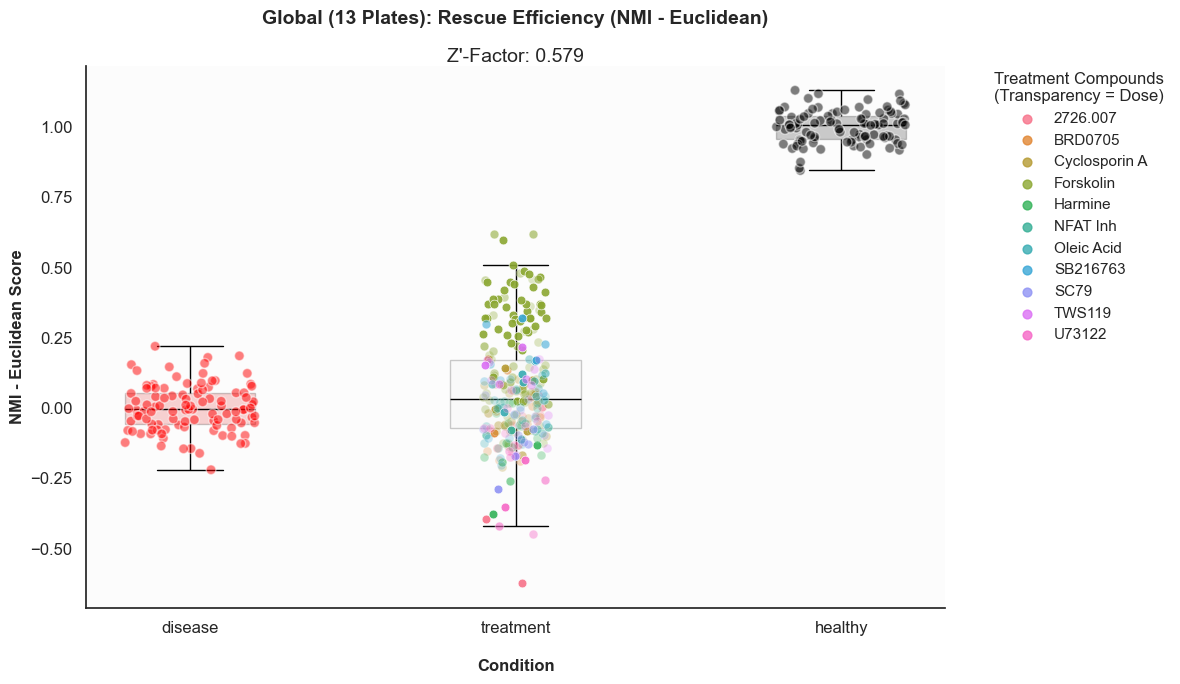

In [4936]:
print("="*60)
print(f"1. COMPUTE NMI")
print("="*60)
print()

# # Use level 'plate' to calculate NMI per plate or None to calculate globally
# distance_metric = 'euclidean'
# df_nmi = calculate_nmi(df_pca, n_pcs=10, level=None, metric=distance_metric)
# plot_rescue_summary(df_nmi, 'nmi_score', f'NMI - {distance_metric.capitalize()}')

# Use level 'plate' to calculate NMI per plate or None to calculate globally
distance_metric = 'euclidean'
df_nmi = calculate_nmi(df_selected_features, n_pcs=None, level=None, metric=distance_metric)
plot_rescue_summary(df_nmi, 'nmi_score', f'NMI - {distance_metric.capitalize()}')

2. COMPUTE DISTANCE TO HEALTHY

Euclidean distance to 'healthy' | level=None | 5 features
  Global Results → Z-Factor: 0.519
Final Average Stats: healthy mean=1.00 | disease mean=0.00 | treatment mean=0.05


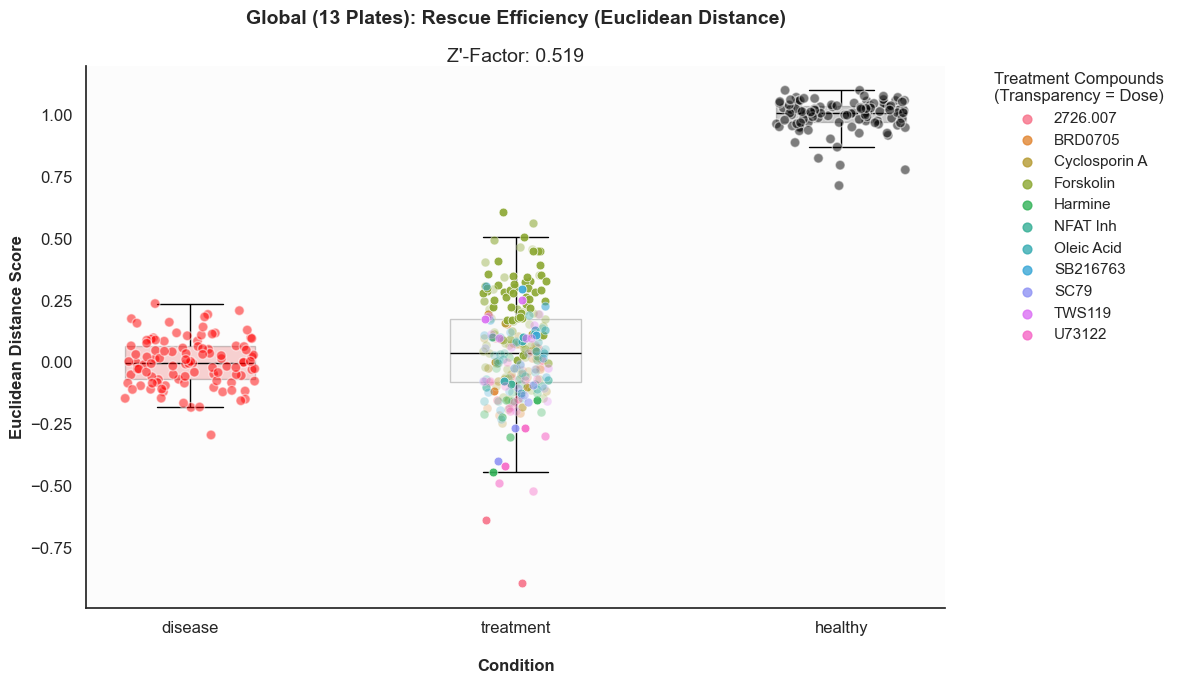

In [4937]:
print("="*60)
print(f"2. COMPUTE DISTANCE TO HEALTHY")
print("="*60)
print()

distance_metric = 'euclidean'
df_distance = calculate_ref_distance(df_pca, n_pcs=5, metric=distance_metric, level=None, reference='healthy')
plot_rescue_summary(df_distance, 'dist_score',  f'{distance_metric.capitalize()} Distance')

# distance_metric = 'euclidean'
# df_distance = calculate_ref_distance(df_selected_features, n_pcs=None, metric=distance_metric, level=None, reference='healthy')
# plot_rescue_summary(df_distance, 'dist_score',  f'{distance_metric.capitalize()} Distance')

3. COMPUTE SIMILARITY SCORE

Similarity to 'healthy' (cosine) | level=None | 5 dimensions
  Global Results → Z-Factor: 0.910

Final Average Stats: disease mean=0.00 | treatment mean=0.07 | healthy mean=1.00


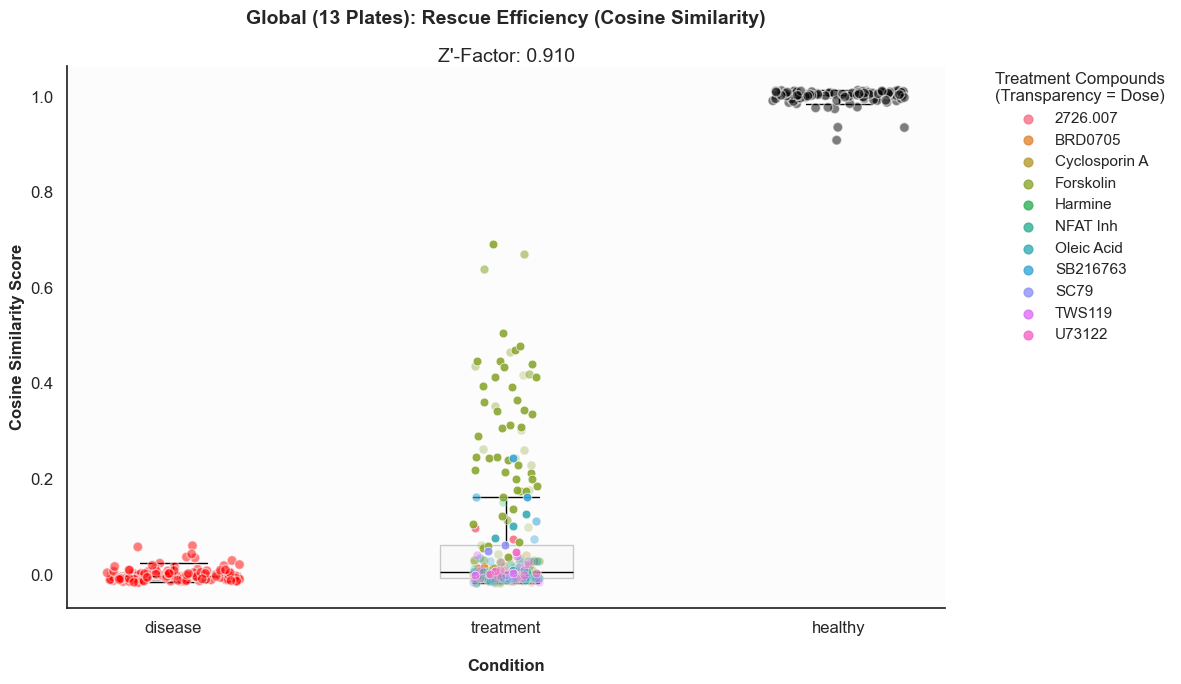

In [4938]:
print("="*60)
print(f"3. COMPUTE SIMILARITY SCORE")
print("="*60)
print()

similarity_metric = 'cosine' # spearman, kendall do not work with pca data; use cosine or pearson instead
df_similarity = calculate_ref_similarity(df_pca, n_pcs=5, metric=similarity_metric, level=None, reference='healthy')
plot_rescue_summary(df_similarity, 'sim_score',  f'{similarity_metric.capitalize()} Similarity')

# similarity_metric = 'pearson'
# df_similarity = calculate_ref_similarity(df_selected_features, n_pcs=None, metric=similarity_metric, level=None, reference='healthy')
# plot_rescue_summary(df_similarity, 'sim_score',  f'{similarity_metric.capitalize()} Similarity')

4. COMPUTE CONSENSUS PHENOTYPIC RESCUE (CPR)

Step 1: Calculating Distance-based rescue...
Euclidean distance to 'healthy' | level=None | 5 features
  Global Results → Z-Factor: 0.519
Final Average Stats: healthy mean=1.00 | disease mean=0.00 | treatment mean=0.05

Step 2: Calculating Similarity-based rescue...
Similarity to 'healthy' (cosine) | level=None | 5 dimensions
  Global Results → Z-Factor: 0.910

Final Average Stats: disease mean=0.00 | treatment mean=0.07 | healthy mean=1.00


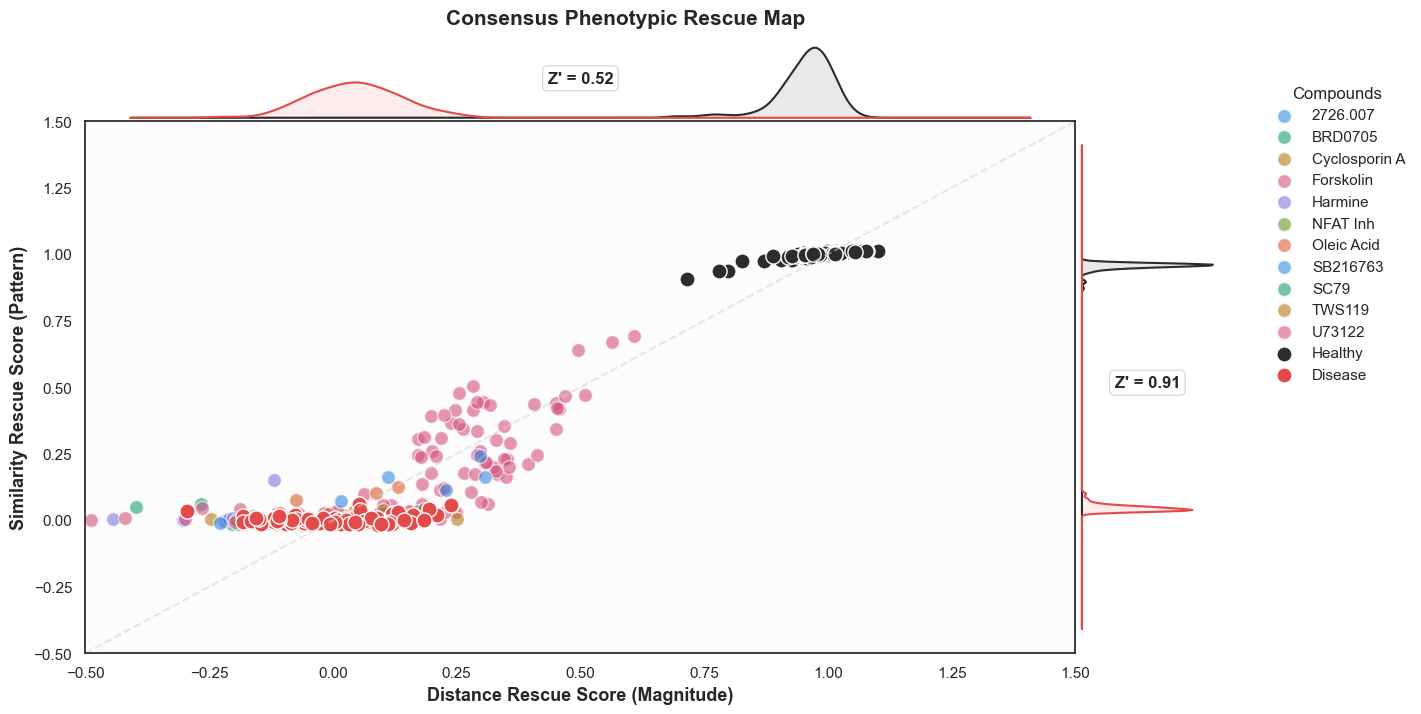

In [4939]:
print("="*60)
print("4. COMPUTE CONSENSUS PHENOTYPIC RESCUE (CPR)")
print("="*60)
print()

# 1. Define your metrics
dist_metric = 'euclidean'
sim_metric = 'cosine'

# 2. Run combined workflow
df_cpr = calculate_consensus_rescue(df_pca, n_pcs = 5, dist_metric=dist_metric, sim_metric=sim_metric, level=None, reference='healthy',
    drift_penalty=0.1, # Adjust this if you want to be stricter on "drifting" compounds
    plot=True
)

In [4940]:
print("="*60)
print(f"6. COMPUTE SUPERVISED SCORES")
print("="*60)
print()

print("Calculate Logistic Regression Effectiveness score...")
method = 'LR' # Logistic Regression (LR) or SVM
df_supervised_lr = calculate_supervised_rescue(df_selected_features, method='LR')
# plot_rescue_summary(df_supervised, 'lr_score',  f'{method}')

print("\n" + "-" * 60)
print("\nCalculate SVM Effectiveness score....")
method = 'SVM' # Logistic Regression (LR) or SVM
df_supervised_svm = calculate_supervised_rescue(df_selected_features, method='SVM')
# plot_rescue_summary(df_supervised, 'svm_score',  f'{method}')

6. COMPUTE SUPERVISED SCORES

Calculate Logistic Regression Effectiveness score...
Supervised Rescue (LR) | 57 dimensions
Global LR Model Report
  Internal CV Accuracy: 1.0000
  Hold-out Test Accuracy: 1.0000
  Hold-out Test AUC: 1.0000

LR Treatment Insight
  Treatment Rescue Mean: 0.0598 (σ=0.1954)
  Separation from Disease Mean: 0.73 SDs

------------------------------------------------------------

Calculate SVM Effectiveness score....
Supervised Rescue (SVM) | 57 dimensions
Global SVM Model Report
  Hold-out Test Accuracy: 1.0000
  Hold-out Test AUC: 1.0000

SVM Treatment Insight
  Treatment Rescue Mean: 0.0428 (σ=0.1711)
  Separation from Disease Mean: 0.54 SDs


7. COMBINE ALL SCORES AND EVALUATE

Combined score dfs successfully: (471, 14)

Pipeline started: 471 total wells processed.
  Metrics detected: nmi_score, cpr_score, lr_score, svm_score
  Filtering complete: Removed 136 toxic wells.
  Aggregation complete: 11 compounds evaluated.


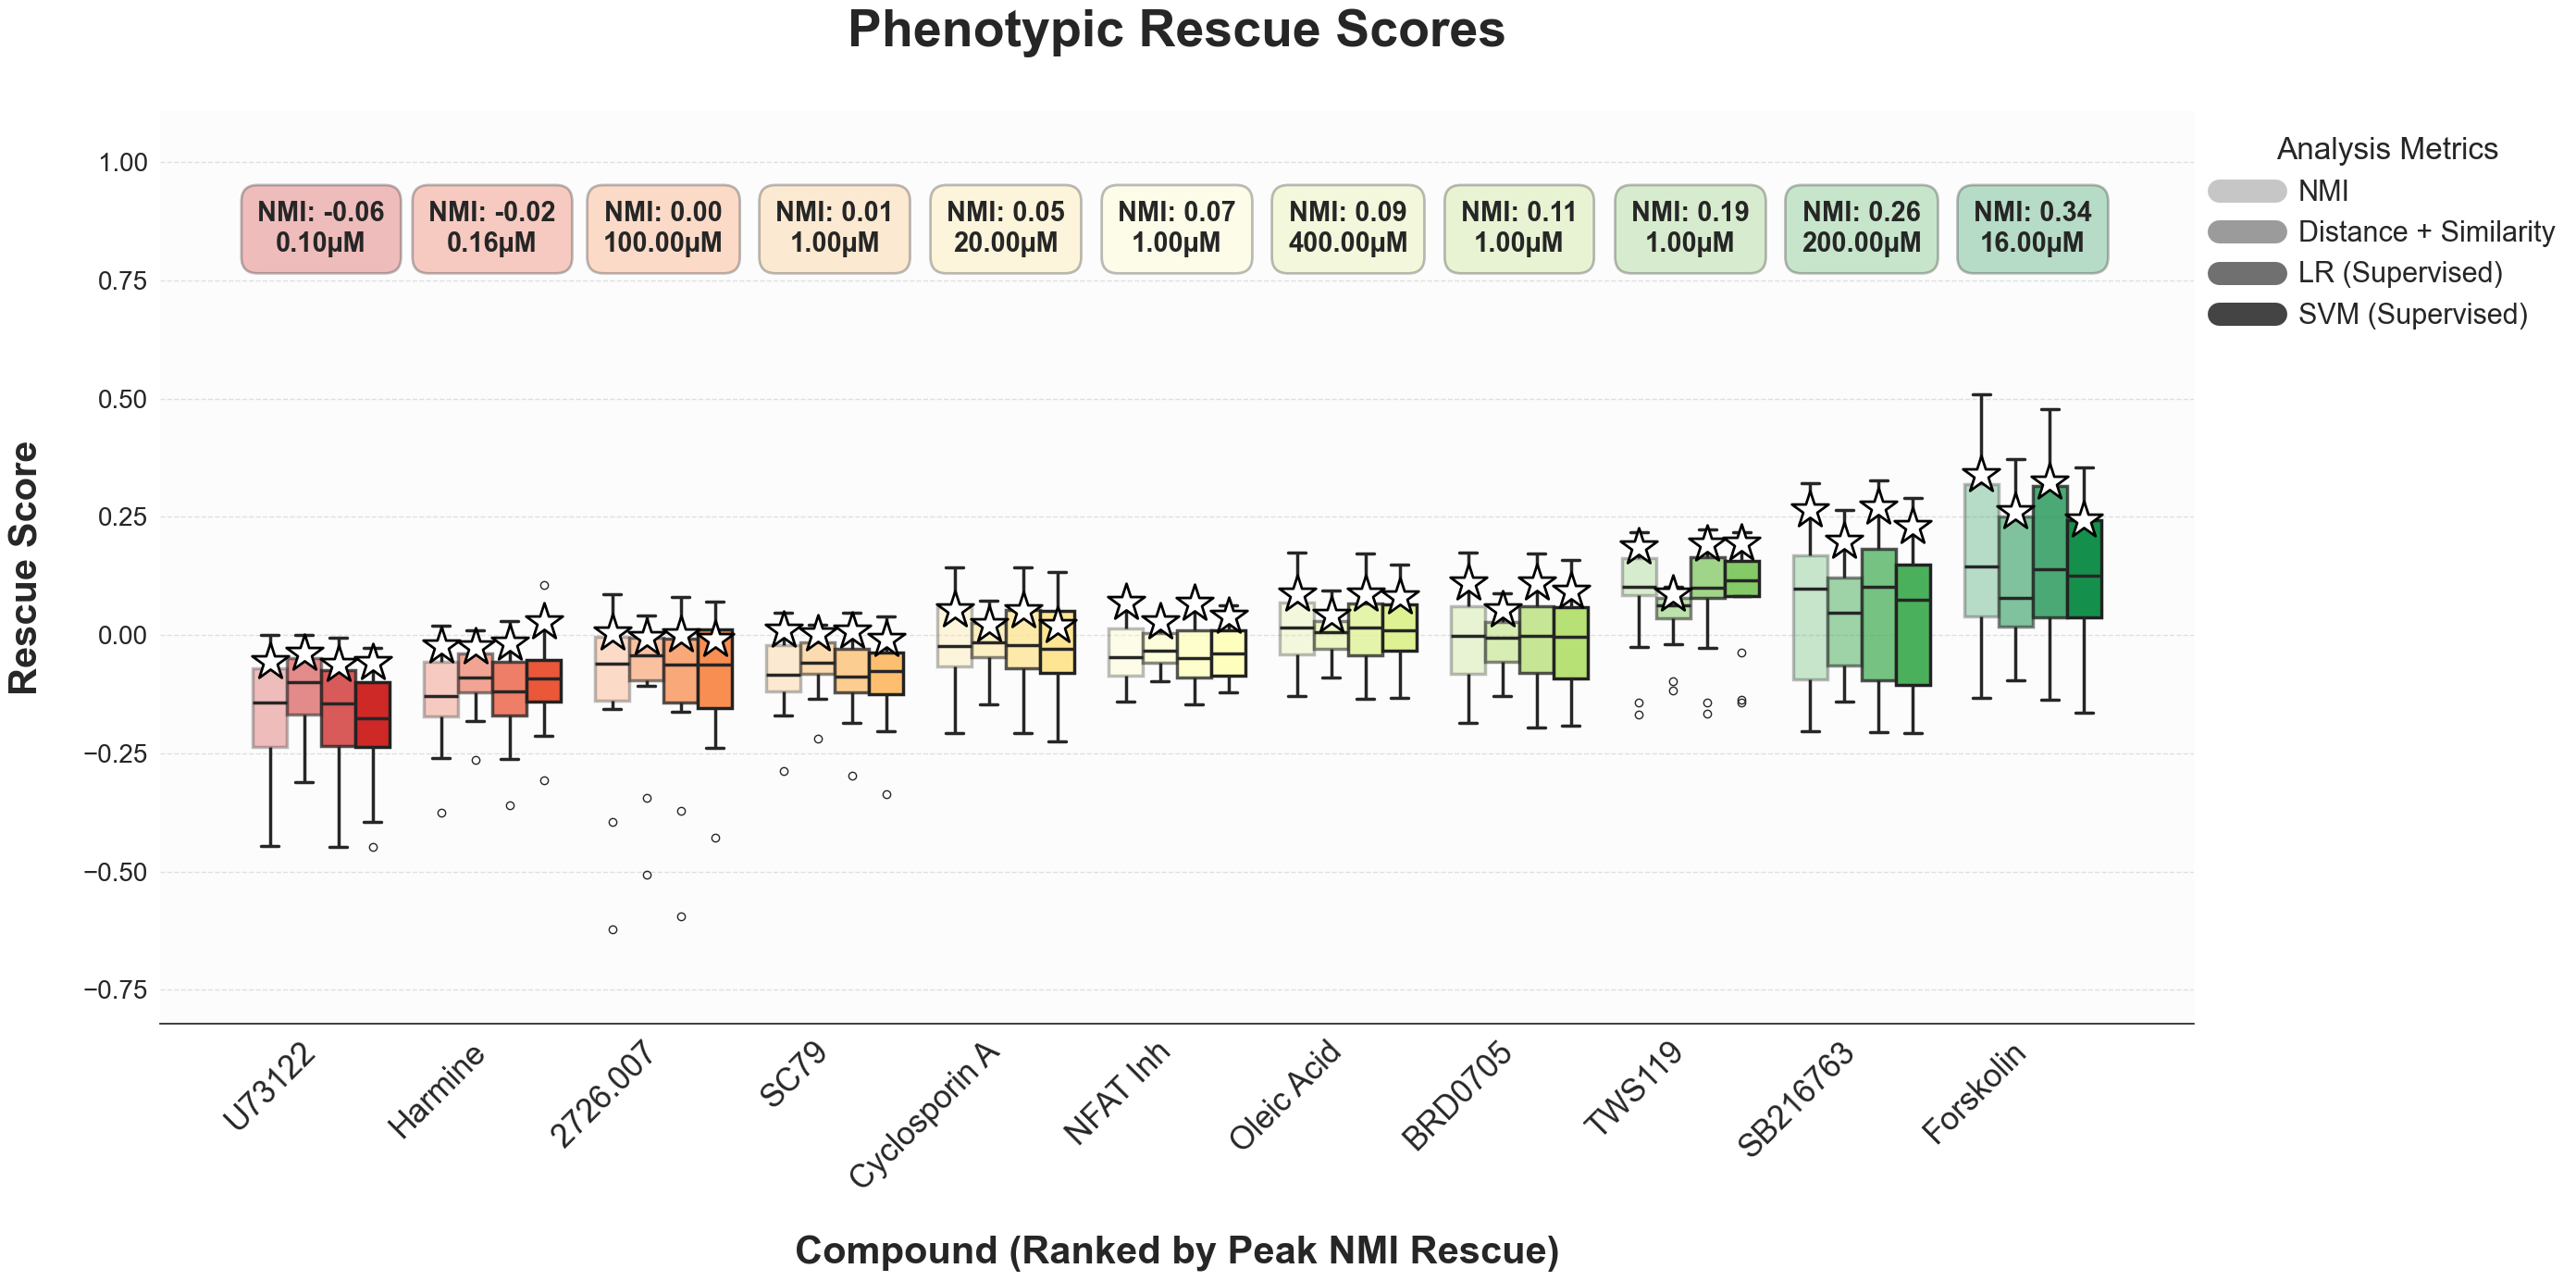


NMI Rescue Results:


,compound,nmi_rescue,nmi_peak_dose,nmi_active_doses,nmi_density
0,Forskolin,0.339877,16.00000,7,5.246370
1,SB216763,0.264197,200.00000,7,5.481970
2,TWS119,0.185620,1.00000,7,4.452747
3,BRD0705,0.109594,1.00000,7,4.512018
4,Oleic Acid,0.087230,400.00000,7,2.940448
5,NFAT Inh,0.069250,1.00000,7,6.436625
6,Cyclosporin A,0.053797,20.00000,7,3.621678
7,SC79,0.010828,1.00000,7,5.487945
8,2726.007,0.004309,100.00000,7,3.326137
9,Harmine,-0.022251,0.15625,7,6.738297


In [4941]:
print("="*60)
print(f"7. COMBINE ALL SCORES AND EVALUATE")
print("="*60)
print()

# 1. Create df with combined scores
keys = list(META_COLS)
# List of dfs with only the score columns
dfs_to_join = [
    df_nmi[keys + ['nmi_score']],
    df_cpr[keys + ['cpr_score']],
    df_supervised_lr[keys + ['lr_score']],
    df_supervised_svm[keys + ['svm_score']]
]
# Combine all score dfs using metadata as keys
df_combined = pd.concat([d.set_index(keys) for d in dfs_to_join], axis=1).reset_index()

print(f"Combined score dfs successfully: {df_combined.shape}\n")

# 2. Evaluate overall compound and plot
# Rank/annote results by a specific metrics
ranking_metric = 'nmi' # Change to 'lr', 'svm', 'cpr', or 'nmi'
hoechst_area = 'Nuclei - CellPainting Nucleus Region Area [µm²] - Median per Well'

df_final_scores, df_clean = evaluate_compounds(
    df_combined, 
    df_all,
    hoechst_col=hoechst_area,
    tox_threshold=0.8,    # Keep wells with >80% area compared to controls
    noise_threshold=0.01,  # Keep doses with >1% rescue signal
    window_size=1,    # Maximum average of {window_size} consecutive doses, using 1 just takes the max rescue score
    plot=True,
    ranking_metric=ranking_metric
)

# Print results for specific metric
print(f"\n{ranking_metric.upper()} Rescue Results:")
# Show table, arranged by rescue
df_final_scores.filter(regex=f"compound|{ranking_metric}_").sort_values(f"{ranking_metric}_rescue", ascending=False)